In [2]:
# import required libraries and loads dataset
import pandas as pd
import numpy as np
try:
    credit_default_dataframe = pd.read_csv("/content/train_data.csv")
    #Check the dataset is not empty
    if credit_default_dataframe.empty:
        raise ValueError("Loaded dataset is empty.")
    # Display dataset summary
    print("Dataset loaded successfully!!!!")
    print(f"Shape: {credit_default_dataframe.shape}")
    print("\nFirst 5 rows:")
    display(credit_default_dataframe.head())
except FileNotFoundError as file_error:
    print(f"File Error: {file_error}")
except pd.errors.ParserError as parser_error:
    print(f"Parsing Error: Unable to read CSV file : {parser_error}")
except ValueError as value_error:
    print(f"Validation Error: {value_error}")
except Exception as unexpected_error:
    print(f"Unexpected Error: {unexpected_error}")

Dataset loaded successfully!!!!
Shape: (153755, 122)

First 5 rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,410704,0,Cash loans,F,N,Y,1,157500.0,900000.0,26446.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,381230,0,Cash loans,F,N,Y,1,90000.0,733176.0,21438.0,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,1.0
2,450177,0,Cash loans,F,Y,Y,0,189000.0,1795500.0,62541.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,332445,0,Cash loans,M,Y,N,0,175500.0,494550.0,45490.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,357429,0,Cash loans,F,Y,Y,0,270000.0,1724688.0,54283.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
#initial data exploratiom to understand the data quality and target balance
try:
    print("Basic Dataset Information")
    #shape
    total_rows, total_columns = credit_default_dataframe.shape
    print(f"Total Rows    : {total_rows}")
    print(f"Total Columns : {total_columns}")
    # check duplicate
    duplicate_record_count = credit_default_dataframe.duplicated().sum()
    print(f"\nDuplicate Rows: {duplicate_record_count}")
    #missing value analysis
    missing_value_summary = credit_default_dataframe.isnull().sum()
    columns_with_missing_values = missing_value_summary[missing_value_summary > 0]
    print(f"\nColumns with Missing Values: {len(columns_with_missing_values)}")
    if len(columns_with_missing_values) > 0:
        missing_percentage = (
            columns_with_missing_values / total_rows
        ).sort_values(ascending=False) * 100
        missing_value_report = pd.DataFrame({
            "Missing_Count": columns_with_missing_values,
            "Missing_Percentage": missing_percentage
        }).sort_values(
            by="Missing_Percentage",
            ascending=False
        )
        print("\nTop 10 columns with missing values:")
        display(missing_value_report.head(10))
    #data types summary
    print("\nFeature Datatype Summary!!!")
    print(credit_default_dataframe.dtypes.value_counts())
    # Target distribution
    print("\nTarget Variable Distribution!!!")
    target_distribution = credit_default_dataframe["TARGET"].value_counts()
    target_percentage = (
        credit_default_dataframe["TARGET"]
        .value_counts(normalize=True) * 100
    )
    target_summary = pd.DataFrame({
        "Count": target_distribution,
        "Percentage": target_percentage
    })
    display(target_summary)
except KeyError as key_error:
    print(f"Column Error: {key_error}")
except Exception as unexpected_error:
    print(f"Unexpected Error: {unexpected_error}")

Basic Dataset Information
Total Rows    : 153755
Total Columns : 122

Duplicate Rows: 0

Columns with Missing Values: 66

Top 10 columns with missing values:


,Missing_Count,Missing_Percentage
COMMONAREA_AVG,107523,69.931384
COMMONAREA_MODE,107523,69.931384
COMMONAREA_MEDI,107523,69.931384
NONLIVINGAPARTMENTS_MODE,106918,69.537901
NONLIVINGAPARTMENTS_AVG,106918,69.537901
NONLIVINGAPARTMENTS_MEDI,106918,69.537901
LIVINGAPARTMENTS_MEDI,105193,68.415986
LIVINGAPARTMENTS_MODE,105193,68.415986
LIVINGAPARTMENTS_AVG,105193,68.415986
FONDKAPREMONT_MODE,105177,68.405580



Feature Datatype Summary!!!
float64    65
int64      41
object     16
Name: count, dtype: int64

Target Variable Distribution!!!


,Count,Percentage
TARGET,,
0,141343,91.927417
1,12412,8.072583


### Interpretation of Initial Data Exploration

The initial exploration of the credit default dataset provides several important insights that directly influence the modeling strategy.

1. **Dataset Size and Structure**
   - The dataset contains 153,755 observations and 122 features, which is sufficiently large for building a reliable predictive model.
   - No duplicate records were identified, indicating good overall data integrity.

2. **Missing Value Analysis**
   - A total of 66 columns contain missing values, with several variables showing more than 65% missingness.
   - Features such as COMMONAREA_AVG, NONLIVINGAPARTMENTS_MODE, and LIVINGAPARTMENTS_AVG contain substantial missing data, suggesting that missing value handling will be an essential preprocessing  engineering step.

3. **Feature Types**
   - The dataset contains:
     - 65 numerical (float) features
     - 41 integer features
     - 16 categorical (object) features
   - This mixed feature structure indicates that categorical encoding will be required before training machine learning models.

4. **Class Imbalance**
   - The target variable TARGET is highly imbalanced:
     - 91.93% belong to class 0 (non default)
     - 8.07% belong to class 1 (default)
    - This imbalance suggests that evaluation metrics beyond accuracy, such as Precision, Recall, and F1-score, should be considered when comparing model performance.
### Conclusion
These findings justify the next steps of:
- selecting a meaningful subset of no more than 20 predictor variables,
- preprocessing missing and categorical values,
- building a single Decision Tree model,
- developing a Random Forest model,
- and comparing both models based on performance and generalization ability.

In [4]:
#transform Time-Based Features
try:
    #convert age from negative days to positive years
    credit_default_dataframe["AGE_YEARS"] = (
        abs(credit_default_dataframe["DAYS_BIRTH"]) / 365
    ).round(1)
    #convert employment days to years
    credit_default_dataframe["EMPLOYED_YEARS"] = (
        abs(credit_default_dataframe["DAYS_EMPLOYED"]) / 365
    ).clip(upper=50).round(1)
    #phone change in years
    credit_default_dataframe["PHONE_CHANGE_YEARS"] = (
        abs(credit_default_dataframe["DAYS_LAST_PHONE_CHANGE"]) / 365
    ).round(1)
    print("Time based feature transformation completed.")
    display(
        credit_default_dataframe[
            ["AGE_YEARS", "EMPLOYED_YEARS", "PHONE_CHANGE_YEARS"]
        ].head()
    )
except KeyError as key_error:
    print(f"Column Error: {key_error}")
except Exception as transformation_error:
    print(f"Unexpected Error: {transformation_error}")

Time based feature transformation completed.


,AGE_YEARS,EMPLOYED_YEARS,PHONE_CHANGE_YEARS
0,44.3,5.6,4.8
1,41.0,0.4,9.0
2,60.9,50.0,0.0
3,52.9,50.0,5.4
4,50.4,2.4,1.9


### Interpretation of Time Based Feature Transformation

Several time related variables in the dataset were originally stored as negative values measured in days, which are difficult to interpret directly in a machine learning model.

1. Age Transformation
   - DAYS_BIRTH was converted into a new variable called AGE_YEARS by taking the absolute value and converting days into years.
   - This makes model interpretation more intuitive, especially when visualizing decision tree splits.

2. Employment Duration Transformation
   - DAYS_EMPLOYED was converted into    EMPLOYED_YEARS.
   - The dataset contains a known placeholder value of 365243, which represents missing or special employment status.
   - Instead of removing these records, employment duration was capped at 50 years to reduce the impact of this anomaly while preserving all observations.

3. Phone Change Duration
   - DAYS_LAST_PHONE_CHANGE was converted into PHONE_CHANGE_YEARS to improve interpretability.
   - Although this feature was created for exploratory purposes, it may or may not be included in the final model depending on feature selection constraints.

### Conclusion
These transformations improve feature interpretability, reduce the effect of data anomalies, and produce more meaningful decision rules when visualizing the classification tree.

In [5]:
#select Target and <=20 Features
try:
    #remove customer ID column
    if "SK_ID_CURR" in credit_default_dataframe.columns:
        credit_default_dataframe = credit_default_dataframe.drop(
            columns=["SK_ID_CURR"]
        )
    #define target column
    target_variable = "TARGET"
    #select 20 meaningful predictor variables
    selected_feature_columns = [
            "NAME_CONTRACT_TYPE",
            "CODE_GENDER",
            "FLAG_OWN_CAR",
            "FLAG_OWN_REALTY",
            "CNT_CHILDREN",
            "AMT_INCOME_TOTAL",
            "AMT_CREDIT",
            "AMT_ANNUITY",
            "AMT_GOODS_PRICE",
            "NAME_INCOME_TYPE",
            "NAME_EDUCATION_TYPE",
            "NAME_FAMILY_STATUS",
            "AGE_YEARS",
            "EMPLOYED_YEARS",
            "REGION_POPULATION_RELATIVE",
            "EXT_SOURCE_1",
            "EXT_SOURCE_2",
            "EXT_SOURCE_3",
            "CNT_FAM_MEMBERS",
            "AMT_REQ_CREDIT_BUREAU_YEAR"
    ]
    #create feature matrix and target vector
    feature_matrix = credit_default_dataframe[selected_feature_columns]
    target_vector = credit_default_dataframe[target_variable]
    print("Feature and target selection completed!!!!")
    print(f"Selected Features: {len(selected_feature_columns)}")
    print("Feature Names:")
    print(selected_feature_columns)
    print(f"Feature Matrix Shape: {feature_matrix.shape}")
    print(f"Target Vector Shape: {target_vector.shape}")
except KeyError as missing_column_error:
    print(f"Missing Column Error: {missing_column_error}")
except Exception as feature_selection_error:
    print(f"Unexpected Error: {feature_selection_error}")

Feature and target selection completed!!!!
Selected Features: 20
Feature Names:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'AGE_YEARS', 'EMPLOYED_YEARS', 'REGION_POPULATION_RELATIVE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'CNT_FAM_MEMBERS', 'AMT_REQ_CREDIT_BUREAU_YEAR']
Feature Matrix Shape: (153755, 20)
Target Vector Shape: (153755,)


### Interpretation of Feature Selection

The selected features include a combination of:

- Demographic variables such as AGE_YEARS,  CODE_GENDER, and CNT_CHILDREN,
- Financial variables such as AMT_INCOME_TOTAL, AMT_CREDIT, and AMT_ANNUITY,
- External risk indicators (EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3),
- Credit behavior variables such as AMT_REQ_CREDIT_BUREAU_YEAR,
- and categorical borrower profile variables such as NAME_INCOME_TYPE and NAME_EDUCATION_TYPE.

This combination was chosen to provide a balanced representation of customer demographics, financial capacity, and historical credit risk.

The resulting feature matrix contains 153,755 observations and 20 predictor variables, while the target vector contains 153,755 target labels, confirming that the dataset is ready for preprocessing and model preparation.

In [6]:
# train test split
from sklearn.model_selection import train_test_split
try:
    #split dataset using stratification because of class imbalance
    (
        training_features,
        testing_features,
        training_target,
        testing_target
    ) = train_test_split(
        feature_matrix,
        target_vector,
        test_size=0.20,
        random_state=42,
        stratify=target_vector
    )
    #create copies
    training_features = training_features.copy()
    testing_features = testing_features.copy()
    print("Train test split completed successfully!!")
    print(f"Training feature shape: {training_features.shape}")
    print(f"Testing feature shape : {testing_features.shape}")
except Exception as split_error:
    print(f"Unexpected Error: {split_error}")

Train test split completed successfully!!
Training feature shape: (123004, 20)
Testing feature shape : (30751, 20)


### Interpretation of Train Test Split

The dataset is divided into training and testing subsets using an 80:20 split.

- The training set contains 123,004 observations and will be used to train both the Decision Tree and Random Forest models.
- The testing set contains 30,751 observations and will be used to evaluate model generalization on unseen data.

A stratified split is applied using the target variable (TARGET) to preserve the original class distribution in both subsets. This is especially important because the dataset is highly imbalanced, with only a small proportion of default cases.

Using a fixed random_state = 42 ensures that the results are reproducible.

In [7]:
#impute missing values and encode
try:
    #identify column types
    numerical_feature_columns = training_features.select_dtypes(
        include=["int64", "float64"]
    ).columns
    categorical_feature_columns = training_features.select_dtypes(
        include=["object"]
    ).columns
    #nnumerical median imputation
    training_medians = training_features[
        numerical_feature_columns
    ].median()
    training_features[numerical_feature_columns] = (
        training_features[numerical_feature_columns]
        .fillna(training_medians)
    )
    testing_features[numerical_feature_columns] = (
        testing_features[numerical_feature_columns]
        .fillna(training_medians)
    )
    #categorical mode imputation
    training_modes = (
        training_features[categorical_feature_columns]
        .mode()
        .iloc[0]
    )
    training_features[categorical_feature_columns] = (
        training_features[categorical_feature_columns]
        .fillna(training_modes)
    )
    testing_features[categorical_feature_columns] = (
        testing_features[categorical_feature_columns]
        .fillna(training_modes)
    )
    #one hot encoding
    training_features_encoded = pd.get_dummies(
        training_features,
        drop_first=True
    )
    testing_features_encoded = pd.get_dummies(
        testing_features,
        drop_first=True
    )
    #align columns
    training_features_encoded, testing_features_encoded = (
        training_features_encoded.align(
            testing_features_encoded,
            join="left",
            axis=1,
            fill_value=0
        )
    )
    print("Imputation and encoding completed successfully!!!!")
    print(
        f"Final training shape: "
        f"{training_features_encoded.shape}"
    )
    print(
        f"Final testing shape: "
        f"{testing_features_encoded.shape}"
    )
except Exception as preprocessing_error:
    print(f"Unexpected Error: {preprocessing_error}")

Imputation and encoding completed successfully!!!!
Final training shape: (123004, 32)
Final testing shape: (30751, 32)


### Interpretation of Missing Value Handling and Encoding

To prepare the dataset for machine learning, additional preprocessing was performed after the train test split.

1. Missing Value Imputation
   - Numerical variables were imputed using the median of the training set.
   - Categorical variables were imputed using the mode (most frequent value) of the training set.
   - Training statistics were applied to both training and testing datasets to prevent data leakage.

2. Categorical Encoding
   - Since machine learning models require numerical input, categorical variables were transformed using one hot encoding.
   - The drop_first=True option was used to reduce redundancy and avoid multicollinearity.

3. Feature Alignment
   - After encoding, training and testing datasets were aligned to ensure they contained identical predictor columns.

### Result
- The training dataset now contains 123,004 observations and 32 encoded features.
- The testing dataset now contains 30,751 observations and 32 encoded features.

The data is now fully prepared for Decision Tree and Random Forest model training.

In [8]:
#build single decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)
try:
    #initialize decision tree model
    single_decision_tree_model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=7,
        min_samples_split=20,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    )
    #train model
    single_decision_tree_model.fit(
        training_features_encoded,
        training_target
    )
    #generate predictions
    training_predictions_tree = (
        single_decision_tree_model.predict(
            training_features_encoded
        )
    )
    testing_predictions_tree = (
        single_decision_tree_model.predict(
            testing_features_encoded
        )
    )
    #generate probability predictions for ROC AUC
    testing_prediction_probabilities_tree = (
        single_decision_tree_model.predict_proba(
            testing_features_encoded
        )[:, 1]
    )
    #calculate accuracy
    training_accuracy_tree = accuracy_score(
        training_target,
        training_predictions_tree
    )
    testing_accuracy_tree = accuracy_score(
        testing_target,
        testing_predictions_tree
    )
    # calculate ROC-AUC
    tree_auc_score = roc_auc_score(
        testing_target,
        testing_prediction_probabilities_tree
    )
    print("Single Decision Tree model trained successfully!!!")
    print(
        f"Training Accuracy: "
        f"{training_accuracy_tree:.4f}"
    )
    print(
        f"Testing Accuracy : "
        f"{testing_accuracy_tree:.4f}"
    )
    print(
        f"ROC-AUC Score    : "
        f"{tree_auc_score:.4f}"
    )
    #classification report
    print("Decision Tree Classification Report:")
    print(
        classification_report(
            testing_target,
            testing_predictions_tree,
            target_names=[
                "No Default",
                "Default"
            ]
        )
    )
except ValueError as model_value_error:
    print(f"Model Value Error: {model_value_error}")
except MemoryError:
    print("Memory Error: dataset too large for model training.")
except Exception as model_training_error:
    print(
        f"Unexpected Error during model training: "
        f"{model_training_error}"
    )

Single Decision Tree model trained successfully!!!
Training Accuracy: 0.6827
Testing Accuracy : 0.6758
ROC-AUC Score    : 0.7105
Decision Tree Classification Report:
              precision    recall  f1-score   support

  No Default       0.96      0.68      0.79     28269
     Default       0.15      0.64      0.24      2482

    accuracy                           0.68     30751
   macro avg       0.55      0.66      0.52     30751
weighted avg       0.89      0.68      0.75     30751



### Interpretation of Decision Tree Results

The Decision Tree model is trained using class balancing to address the class imbalance present in the credit default dataset.

#### Performance Summary
- Training Accuracy: 0.6827
- Testing Accuracy: 0.6758
- ROC-AUC: 0.7105

#### Key Observations

1. Good Generalization
   - The training and testing accuracies are very close, indicating that the model generalizes well to unseen data and shows minimal overfitting.

2. Improved Default Detection
   - The model achieved a recall of 0.64 for the Default class, meaning it correctly identified 64% of actual defaulters.
   - This is important in credit risk prediction, where detecting risky applicants is a priority.

3. Low Precision for Default Class
   - Precision for the Default class is 0.15, indicating that the model produces a relatively high number of false positives.
   - This suggests the model favors identifying more potential defaulters, even at the cost of incorrectly labeling some non defaulters.

4. Moderate Predictive Performance
   - The ROC AUC score of 0.7105 indicates moderate discriminatory ability, meaning the model performs better than random guessing in distinguishing between defaulters and non defaulters.

### Conclusion
The Decision Tree provides an interpretable baseline model with balanced performance and reasonable default detection capability. However, its predictive performance may be improved further using an ensemble method such as Random Forest.

In [9]:
#build random forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)
try:
    #initialize random forest model
    random_forest_model = RandomForestClassifier(
        n_estimators=100,
        criterion="gini",
        max_depth=7,
        min_samples_split=20,
        min_samples_leaf=20,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )
    #train model
    random_forest_model.fit(
        training_features_encoded,
        training_target
    )
    #generate predictions
    training_predictions_forest = (
        random_forest_model.predict(
            training_features_encoded
        )
    )
    testing_predictions_forest = (
        random_forest_model.predict(
            testing_features_encoded
        )
    )
    #generate probability predictions for ROC AUC
    testing_prediction_probabilities_forest = (
        random_forest_model.predict_proba(
            testing_features_encoded
        )[:, 1]
    )
    #calculate accuracy
    training_accuracy_forest = accuracy_score(
        training_target,
        training_predictions_forest
    )
    testing_accuracy_forest = accuracy_score(
        testing_target,
        testing_predictions_forest
    )
    #calculate ROC AUC
    forest_auc_score = roc_auc_score(
        testing_target,
        testing_prediction_probabilities_forest
    )
    print("Random Forest model trained successfully!!!")
    print(
        f"Training Accuracy: "
        f"{training_accuracy_forest:.4f}"
    )
    print(
        f"Testing Accuracy : "
        f"{testing_accuracy_forest:.4f}"
    )
    print(
        f"ROC-AUC Score    : "
        f"{forest_auc_score:.4f}"
    )
    #classification report
    print("\nRandom Forest Classification Report:")
    print(
        classification_report(
            testing_target,
            testing_predictions_forest,
            target_names=[
                "No Default",
                "Default"
            ]
        )
    )
except ValueError as model_value_error:
    print(f"Model Value Error: {model_value_error}")
except MemoryError:
    print("Memory Error: dataset too large for model training.")
except Exception as model_training_error:
    print(
        f"Unexpected Error during model training: "
        f"{model_training_error}"
    )

Random Forest model trained successfully!!!
Training Accuracy: 0.6991
Testing Accuracy : 0.6946
ROC-AUC Score    : 0.7381

Random Forest Classification Report:
              precision    recall  f1-score   support

  No Default       0.96      0.70      0.81     28269
     Default       0.16      0.65      0.26      2482

    accuracy                           0.69     30751
   macro avg       0.56      0.68      0.53     30751
weighted avg       0.89      0.69      0.76     30751



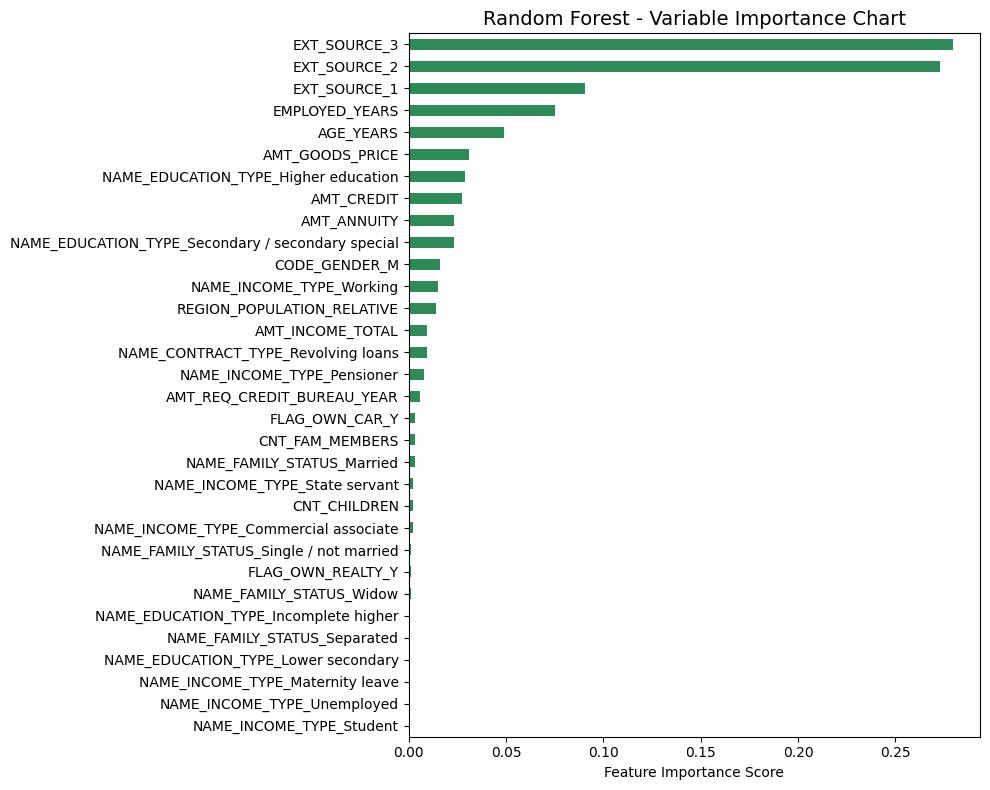

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
# plot random forest feature importance
feat_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=training_features_encoded.columns
).sort_values(ascending=True)
plt.figure(figsize=(10, 8))
feat_importance.plot(kind='barh', color='seagreen')
plt.title('Random Forest - Variable Importance Chart', fontsize=14)
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

### Interpretation of Random Forest Results

The Random Forest model is trained using the same selected features and evaluation metrics as the Decision Tree model to enable a fair comparison.

#### Performance Summary
- Training Accuracy: 0.6991
- Testing Accuracy: 0.6946
- ROC-AUC: 0.7381

#### Key Observations

1. Improved Generalization
   - The training and testing accuracies remain close, indicating that the Random Forest model generalizes well and does not show significant overfitting.

2. Better Overall Predictive Performance
   - The Random Forest achieved higher testing accuracy and a higher ROC-AUC score than the Decision Tree.
   - This indicates stronger ability to distinguish between defaulters and non-defaulters.

3. Improved Minority Class Detection
   - The model achieved a recall of 0.65 for the Default class, slightly improving the detection of risky applicants.

4. Higher Precision for Default Class
   - Precision for the Default class increased to 0.16, meaning fewer false positive default predictions compared to the Decision Tree.

### Conclusion
The Random Forest model outperformed the single Decision Tree across all major evaluation metrics, demonstrating the advantage of ensemble learning for improving predictive performance and model stability.

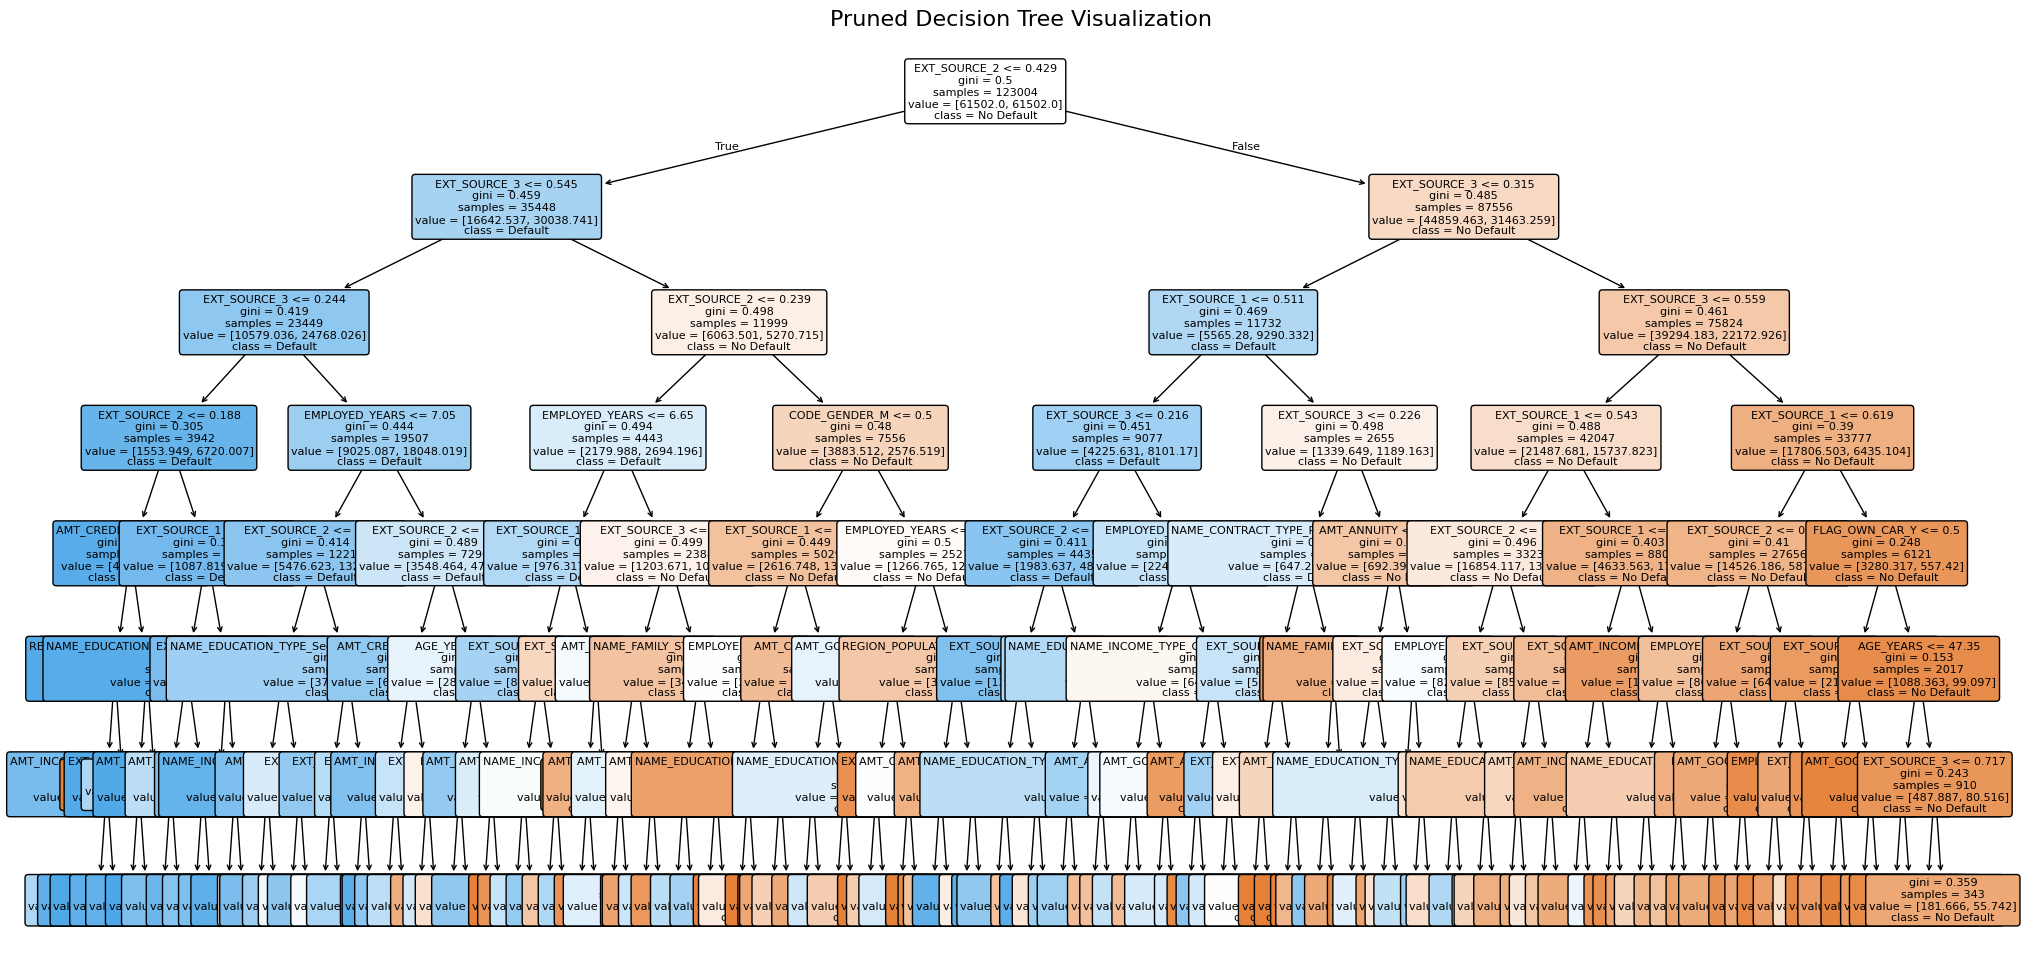

Decision Tree visualization generated successfully!


In [11]:
#visualzie decision tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
try:
    #set figure size
    plt.figure(figsize=(24, 12))
    #plot decision tree
    plot_tree(
        single_decision_tree_model,
        feature_names=training_features_encoded.columns,
        class_names=["No Default", "Default"],
        filled=True,
        rounded=True,
        fontsize=8
    )
    plt.title(
        "Pruned Decision Tree Visualization",
        fontsize=16
    )
    plt.show()
    print("Decision Tree visualization generated successfully!")
except ValueError as plot_value_error:
    print(f"Plot Value Error: {plot_value_error}")
except MemoryError:
    print("Memory Error: unable to render large tree.")
except Exception as visualization_error:
    print(
        f"Unexpected Error during visualization: "
        f"{visualization_error}"
    )

### Interpretation of Decision Tree Visualization

The plotted Decision Tree represents the final pruned classification model used for credit default prediction.

#### Key Observations

1. Tree Pruning
   - The tree was constrained using max_depth = 7, min_samples_split = 20, and min_samples_leaf = 20 to reduce overfitting while maintaining interpretability.

2. Most Important Predictors
   - EXT_SOURCE_2 appears at the root node, indicating it is the most influential variable in separating default and non default customers.
   - EXT_SOURCE_1 and EXT_SOURCE_3 also appear near the top of the tree, highlighting the importance of external credit risk scores.

3. Impact of Engineered Features
   - The engineered variable EMPLOYED_YEARS appears in upper level splits, showing that feature transformation contributed useful predictive information.

4. Model Interpretability
   - The tree provides transparent decision rules, making it easy to understand how predictions are generated an important advantage of Decision Trees.

### Conclusion
Although the Decision Tree is interpretable and provides meaningful business insights, the Random Forest model delivered stronger predictive performance and is therefore the preferred final model.

# Model Comparison: Decision Tree vs Random Forest

## Summary of Results

| Metric | Decision Tree | Random Forest |
|--------|---------------|---------------|
| Training Accuracy | 0.6827 | 0.6991 |
| Testing Accuracy | 0.6758 | 0.6946 |
| ROC-AUC | 0.7105 | 0.7381 |
| Train-Test Gap | 0.0069 | 0.0045 |
| Default Recall | 0.64 | 0.65 |
| Default Precision | 0.15 | 0.16 |

## Key Findings

1. The Random Forest consistently outperforms the Decision Tree across
   all evaluation metrics, particularly ROC AUC, indicating better
   class separation and ranking ability.

2. Both models show minimal overfitting due to applied pruning
   constraints such as max_depth, min_samples_leaf, and
   min_samples_split — the train/test accuracy gap is just 0.0069
   for the Decision Tree and 0.0045 for the Random Forest, confirming
   both generalize well to unseen data.

3. The Random Forest generalizes better due to bootstrap aggregation,
   which reduces variance across individual trees.

4. Accuracy alone is not a reliable metric due to strong class
   imbalance (≈92% non-default cases); hence ROC AUC is more
   representative of true model performance.

## Conclusion

The Random Forest model is more suitable for this credit risk
classification problem due to its higher predictive performance,
improved stability, and better generalization. The Decision Tree,
while slightly weaker in performance, remains valuable for
interpretability and rule-based explanation in regulated settings.